In [1]:
import pandas as pd

df = pd.read_csv('lyrics_emotions.csv')

In [2]:
df

,artist,title,disorder,bert_emotion,bert_confidence,valence,arousal,lyrics_clean
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,joy,0.983130,0.300440,0.333046,Highest To Lowest: Quadeca LyricsQuadeca's Son...
1,Tom Jones,She's A Lady,control,joy,0.503159,0.263476,0.375775,She's a Lady Lyrics Well she's all you'd ever ...
2,David Byrne,Lilies of the Valley,control,sadness,0.994102,0.344658,0.199640,Lilies of the Valley Lyrics Momma she had comp...
3,Alice Cooper,School's Out,control,sadness,0.925512,-0.703709,-0.349047,"School's Out Lyrics Well, we got no choice All..."
4,Shawn Mendes,Call My Friends,depression,sadness,0.859243,-0.976535,-0.977568,"Call My Friends Lyrics Right now, I'm alone in..."
...,...,...,...,...,...,...,...,...
78408,The 1975,Sincerity Is Scary,control,anger,0.654205,-0.821708,0.644341,"Sincerity Is Scary Lyrics Irony is okay, I sup..."
78409,IU,BBIBBI,control,joy,0.634914,0.008630,0.473958,"IU - BBIBBI Lyrics Hi there, say hello without..."
78410,Miley Cyrus,7 Things,control,sadness,0.912925,-0.579800,0.070105,"7 Things Lyrics I probably shouldn't say this,..."
78411,SPM,Mexican Radio,control,anger,0.921523,-0.127482,0.050492,Mexican Radio Lyrics One-double-oh-seven This ...


In [3]:
df['bert_emotion'].unique()

<StringArray>
['joy', 'sadness', 'anger', 'love', 'fear', 'surprise']
Length: 6, dtype: str

Plots for emotions and relation to valence arousal

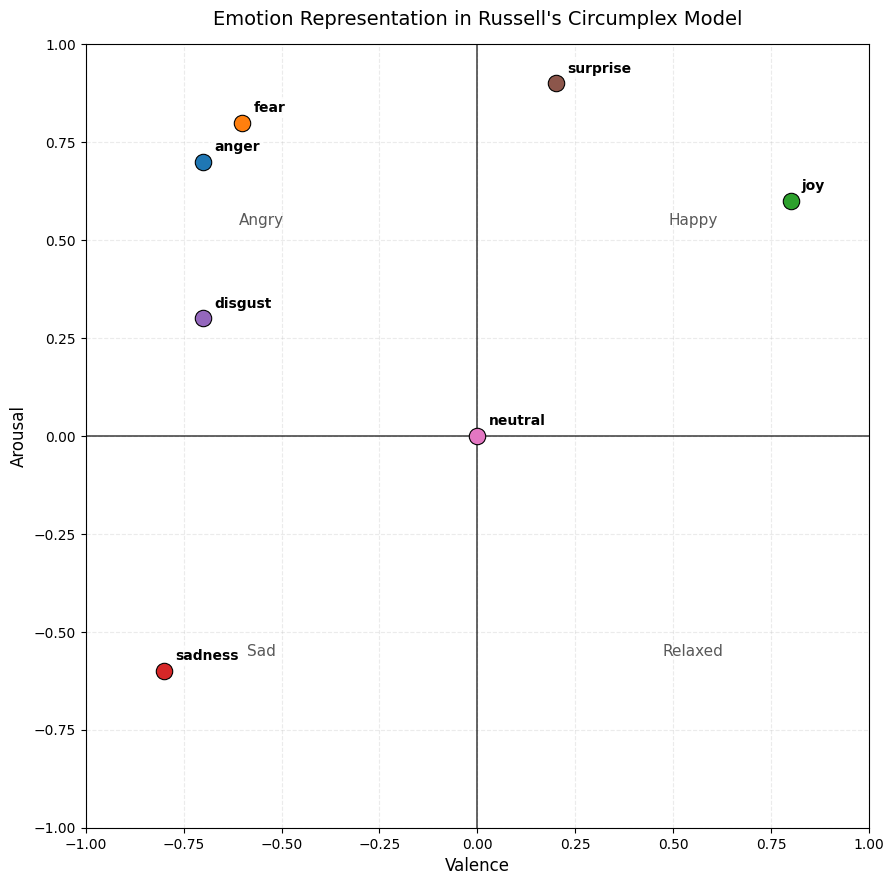

In [4]:
import matplotlib.pyplot as plt

emotions = {
    'anger': (-0.7, 0.7),
    'fear': (-0.6, 0.8),
    'joy': (0.8, 0.6),
    'sadness': (-0.8, -0.6),
    'disgust': (-0.7, 0.3),
    'surprise': (0.2, 0.9),
    'neutral': (0.0, 0.0),
}

fig, ax = plt.subplots(figsize=(9, 9))

for emotion, (valence, arousal) in emotions.items():
    ax.scatter(valence, arousal, s=140, edgecolor='black', linewidth=0.8, zorder=3)
    ax.annotate(
        emotion,
        (valence, arousal),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=10,
        weight='semibold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='none', alpha=0.8)
    )

ax.axhline(0, color='black', linewidth=1.2, alpha=0.7)
ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)

ax.text(0.55, 0.55, 'Happy', ha='center', va='center', fontsize=11, alpha=0.65)
ax.text(-0.55, 0.55, 'Angry', ha='center', va='center', fontsize=11, alpha=0.65)
ax.text(-0.55, -0.55, 'Sad', ha='center', va='center', fontsize=11, alpha=0.65)
ax.text(0.55, -0.55, 'Relaxed', ha='center', va='center', fontsize=11, alpha=0.65)

ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_title("Emotion Representation in Russell's Circumplex Model", fontsize=14, pad=14)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

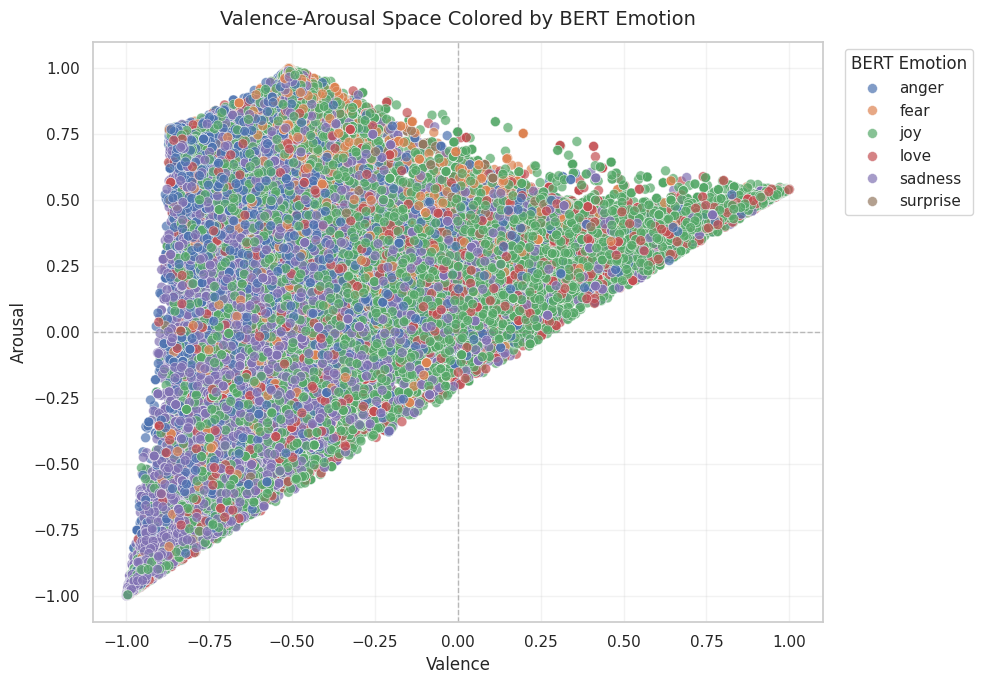

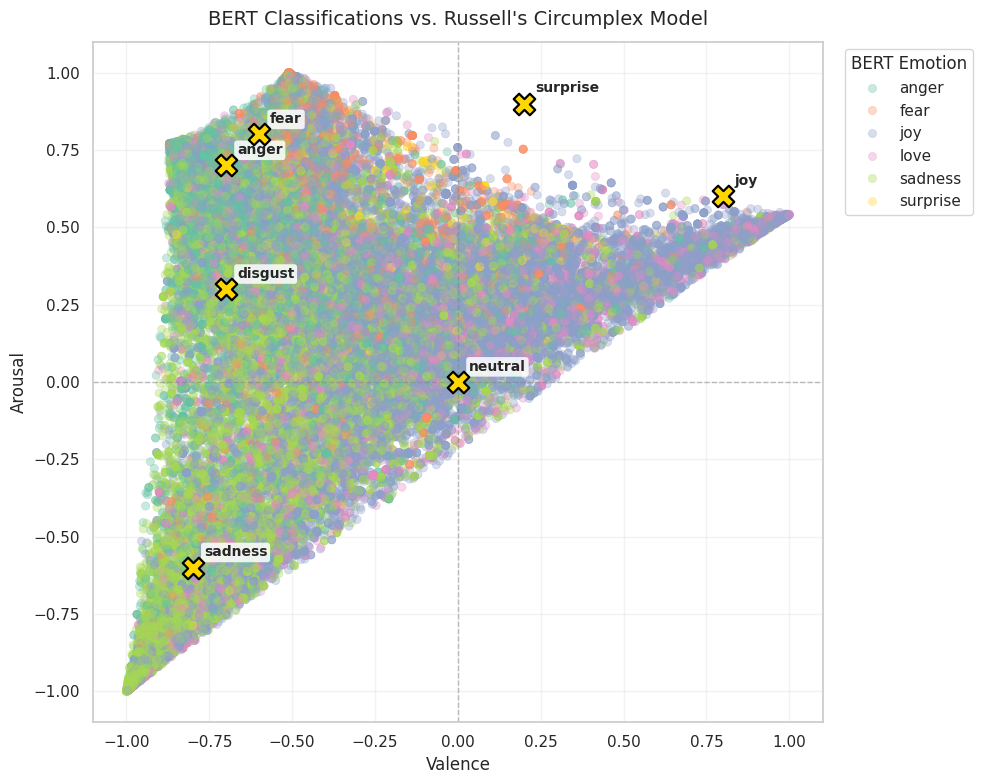

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')

# Find valence & arousal columns
valence_candidates = [c for c in df.columns if 'valence' in c.lower()]
arousal_candidates = [c for c in df.columns if 'arousal' in c.lower()]

if not valence_candidates or not arousal_candidates:
    raise ValueError('No columns found for valence or arousal.')

valence_col = valence_candidates[0]
arousal_col = arousal_candidates[0]

# Find the emotion classification column
emotion_candidates = [c for c in df.columns if 'emotion' in c.lower()]
if not emotion_candidates:
    raise ValueError(f'No emotion column found. Columns: {list(df.columns)}')

emotion_col = emotion_candidates[0]

# Prepare data
plot_df = df[[valence_col, arousal_col, emotion_col]].copy()
emotion_order = sorted(plot_df[emotion_col].dropna().unique().tolist())

# --------- Plot 1: Scatter colored by BERT emotion class ---------
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x=valence_col,
    y=arousal_col,
    hue=emotion_col,
    hue_order=emotion_order,
    alpha=0.7,
    s=50,
    edgecolor='white',
    linewidth=0.4,
    ax=ax
)

ax.set_title('Valence-Arousal Space Colored by BERT Emotion', fontsize=14, pad=12)
ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(alpha=0.25)
ax.legend(title='BERT Emotion', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# --------- Plot 2: Data vs. expected emotion positions ---------
fig, ax = plt.subplots(figsize=(10, 8))

# Plot actual data points
sns.scatterplot(
    data=plot_df,
    x=valence_col,
    y=arousal_col,
    hue=emotion_col,
    hue_order=emotion_order,
    alpha=0.35,
    s=35,
    palette='Set2',
    edgecolor=None,
    ax=ax
)

# Overlay predefined emotion positions from Russell's model
for emotion, (valence, arousal) in emotions.items():
    ax.scatter(valence, arousal, s=240, marker='X', edgecolors='black', linewidth=1.6, color='gold', zorder=6)
    ax.annotate(
        emotion,
        (valence, arousal),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=10,
        weight='semibold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85)
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title("BERT Classifications vs. Russell's Circumplex Model", fontsize=14, pad=12)
ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.25)
ax.legend(title='BERT Emotion', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

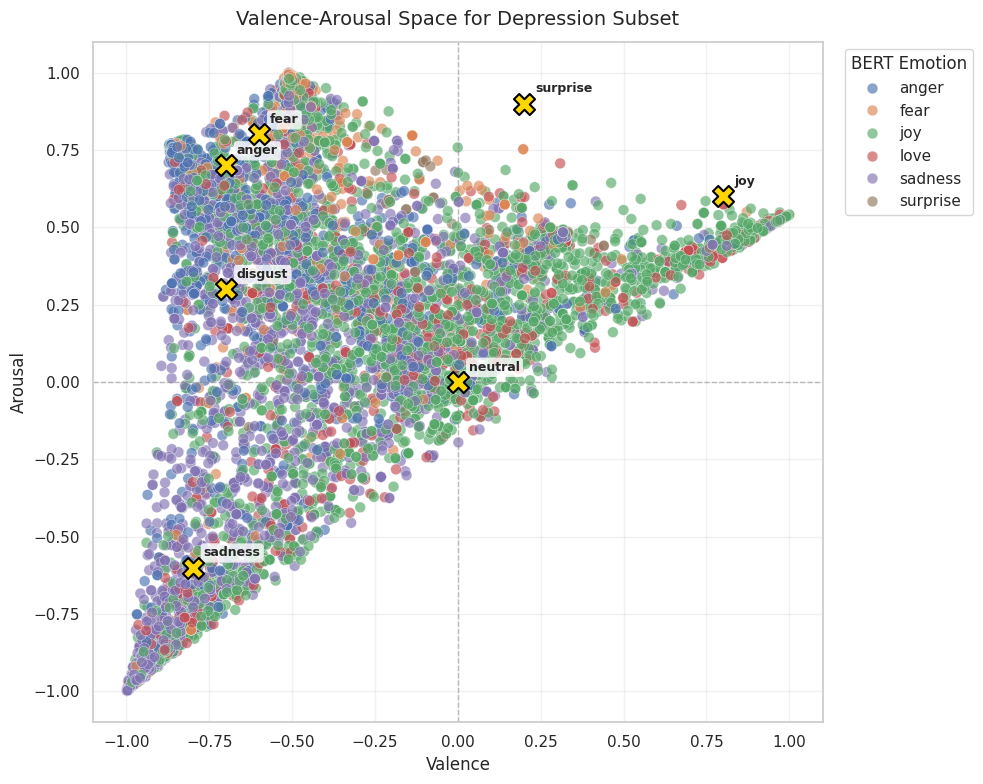

Summary of Valence and Arousal for Depression subset:
bert_emotion
joy         3250
sadness     2482
anger       1187
love         699
fear         530
surprise      69
Name: count, dtype: int64

Average Valence and Arousal for Depression subset:
             valence              arousal             
                mean    std count    mean    std count
bert_emotion                                          
anger         -0.513  0.330  1187   0.340  0.439  1187
fear          -0.414  0.286   530   0.635  0.419   530
joy           -0.213  0.495  3250   0.199  0.476  3250
love          -0.253  0.503   699   0.125  0.508   699
sadness       -0.577  0.350  2482  -0.098  0.614  2482
surprise      -0.027  0.387    69   0.376  0.405    69


In [6]:
depression_df = df[df['disorder'] == 'depression'].copy()

plot_df_depression = depression_df[[valence_col, arousal_col, emotion_col]].copy()
emotion_order_dep = sorted(plot_df_depression[emotion_col].dropna().unique().tolist())

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=plot_df_depression,
    x=valence_col,
    y=arousal_col,
    hue=emotion_col,
    hue_order=emotion_order_dep,
    alpha=0.65,
    s=60,
    palette='deep',
    edgecolor='white',
    linewidth=0.35,
    ax=ax
)

# Reference points
for emotion, (valence, arousal) in emotions.items():
    ax.scatter(valence, arousal, s=230, marker='X', edgecolors='black', linewidth=1.5, color='gold', zorder=6)
    ax.annotate(
        emotion,
        (valence, arousal),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
        weight='semibold',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.8, ec='none')
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Valence-Arousal Space for Depression Subset', fontsize=14, pad=12)
ax.set_xlabel('Valence', fontsize=12)
ax.set_ylabel('Arousal', fontsize=12)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.28)
ax.legend(title='BERT Emotion', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

# Summary
print('Summary of Valence and Arousal for Depression subset:')
print(plot_df_depression[emotion_col].value_counts())

print('\nAverage Valence and Arousal for Depression subset:')
depression_centroids = (
    plot_df_depression.groupby(emotion_col)[[valence_col, arousal_col]]
    .agg(['mean', 'std', 'count'])
    .round(3)
)
print(depression_centroids)

# Plots for the sentiment analysis models

This section includes plots for diagnosing and interpretating the results from training the Go and Vad model.

Note for self: GO is the emotion labels and Vad is the VA values

This sectin includes different plots with focus in the last labels obtained in the end of the twitter notebook

In [7]:
# open the last dataset
lyrics_df = pd.read_csv('model_comparison_20260322_204022.csv')

lyrics_df.head()

,artist,title,disorder,lyrics_clean,go_emotion,go_confidence,go_valence,go_arousal,vad_valence,vad_arousal,va_distance
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,Highest To Lowest: Quadeca LyricsQuadeca's Son...,neutral,0.7992,-0.0373,0.0370,5.2587,5.6958,7.750460
1,Tom Jones,She's A Lady,control,She's a Lady Lyrics Well she's all you'd ever ...,admiration,0.7320,0.7431,0.3167,5.4373,6.1020,7.450182
2,David Byrne,Lilies of the Valley,control,Lilies of the Valley Lyrics Momma she had comp...,neutral,0.6730,0.0757,0.0733,4.3560,5.9713,7.287481
3,Alice Cooper,School's Out,control,"School's Out Lyrics Well, we got no choice All...",neutral,0.5905,-0.2450,0.0458,4.1307,5.8503,7.269042
4,Shawn Mendes,Call My Friends,depression,"Call My Friends Lyrics Right now, I'm alone in...",desire,0.4444,0.1180,0.2536,5.1058,5.7911,7.452654


In [9]:
almost_final = pd.read_csv('lyrics_emotions_almost_final.csv')

almost_final.head()

,artist,title,disorder,bert_emotion,bert_confidence,valence,arousal,lyrics_clean,go_multi_labels,go_multi_scores
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,joy,0.983130,0.300440,0.333046,Highest To Lowest: Quadeca LyricsQuadeca's Son...,disappointment,disappointment:0.0380
1,Tom Jones,She's A Lady,control,joy,0.503159,0.263476,0.375775,She's a Lady Lyrics Well she's all you'd ever ...,admiration | approval,admiration:0.7320 | approval:0.2649
2,David Byrne,Lilies of the Valley,control,sadness,0.994102,0.344658,0.199640,Lilies of the Valley Lyrics Momma she had comp...,approval,approval:0.0948
3,Alice Cooper,School's Out,control,sadness,0.925512,-0.703709,-0.349047,"School's Out Lyrics Well, we got no choice All...",annoyance | disappointment | disapproval,annoyance:0.1691 | disappointment:0.1335 | dis...
4,Shawn Mendes,Call My Friends,depression,sadness,0.859243,-0.976535,-0.977568,"Call My Friends Lyrics Right now, I'm alone in...",desire | disappointment,desire:0.4444 | disappointment:0.1611


I need to merge the datasets and organise how they look like, it's quite baaaad now

In [14]:
import pandas as pd

left_df = lyrics_df.copy()
right_df = almost_final.copy()

# Clean names
left_df.columns = left_df.columns.str.strip()
right_df.columns = right_df.columns.str.strip()

# Normalize aliases so naming is consistent across both datasets
alias_map = {
    "song": "title",
    "go_top_emotion": "go_emotion",
    "go_top_confidence": "go_confidence",
    "go_multi_lables": "go_multi_labels",
    "vad_dominance": "va_distance",   
}

def normalize_aliases(df, aliases):
    df = df.copy()
    for old, new in aliases.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})
        elif old in df.columns and new in df.columns:
            # If both exist, keep one canonical column with first non-null values
            df[new] = df[new].combine_first(df[old])
            df = df.drop(columns=[old])
    return df

left_df = normalize_aliases(left_df, alias_map)
right_df = normalize_aliases(right_df, alias_map)

# Merge keys: prefer artist + title + disorder (or fallback to available subset)
preferred_keys = ["artist", "title", "disorder"]
merge_keys = [k for k in preferred_keys if k in left_df.columns and k in right_df.columns]

if not merge_keys:
    raise ValueError("No valid merge keys found between the two dataframes.")

# Keep only right-side columns that are new (plus keys), to avoid _x/_y duplicates
right_extra_cols = [c for c in right_df.columns if c not in left_df.columns]
right_for_merge = right_df[merge_keys + right_extra_cols].copy()

merged_df = left_df.merge(right_for_merge, on=merge_keys, how="left")

# Exact desired order (using title instead of song)
final_order = [
    "artist",
    "title",
    "disorder",           
    "bert_emotion",
    "bert_confidence",
    "lyrics_clean",
    "go_multi_labels",
    "go_multi_scores",
    "go_emotion",        
    "go_confidence",     
    "go_valence",
    "go_arousal",
    "vad_valence",
    "vad_arousal",
    "va_distance",
    "valence",
    "arousal",      
]

# Ensure all ordered columns exist so order is always followed
for col in final_order:
    if col not in merged_df.columns:
        merged_df[col] = pd.NA

# Keep requested order first; append any remaining columns after
remaining_cols = [c for c in merged_df.columns if c not in final_order]
merged_df = merged_df[final_order + remaining_cols]

print("Merge keys used:", merge_keys)
print("Final shape:", merged_df.shape)

merged_df.to_csv('lyrics_twitter_final.csv', index=False)

Merge keys used: ['artist', 'title', 'disorder']
Final shape: (1338831, 17)
